In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from features import common_preprocessing, get_datasets
from polars import col
from utils import process_fx


In [3]:
raw_df = pl.read_csv("data/train.csv")
raw_df.columns = [
    c.lower().replace("open_interest", "oi").replace("_adj", "") for c in raw_df.columns
]
drops = {"fx_", "settlement_price", "us_stock_gold"}
raw_df = raw_df.drop(c for c in raw_df.columns if any(drop in c for drop in drops))
raw_df = raw_df.fill_null(strategy="forward").fill_null(strategy="backward")


In [4]:
raw_df


date_id,lme_ah_close,lme_ca_close,lme_pb_close,lme_zs_close,jpx_gold_mini_futures_open,jpx_gold_rolling-spot_futures_open,jpx_gold_standard_futures_open,jpx_platinum_mini_futures_open,jpx_platinum_standard_futures_open,jpx_rss3_rubber_futures_open,jpx_gold_mini_futures_high,jpx_gold_rolling-spot_futures_high,jpx_gold_standard_futures_high,jpx_platinum_mini_futures_high,jpx_platinum_standard_futures_high,jpx_rss3_rubber_futures_high,jpx_gold_mini_futures_low,jpx_gold_rolling-spot_futures_low,jpx_gold_standard_futures_low,jpx_platinum_mini_futures_low,jpx_platinum_standard_futures_low,jpx_rss3_rubber_futures_low,jpx_gold_mini_futures_close,jpx_gold_rolling-spot_futures_close,jpx_gold_standard_futures_close,jpx_platinum_mini_futures_close,jpx_platinum_standard_futures_close,jpx_rss3_rubber_futures_close,jpx_gold_mini_futures_volume,jpx_gold_rolling-spot_futures_volume,jpx_gold_standard_futures_volume,jpx_platinum_mini_futures_volume,jpx_platinum_standard_futures_volume,jpx_rss3_rubber_futures_volume,jpx_gold_mini_futures_oi,jpx_gold_rolling-spot_futures_oi,…,us_stock_rio_volume,us_stock_rsp_volume,us_stock_ry_volume,us_stock_scco_volume,us_stock_shel_volume,us_stock_shy_volume,us_stock_slb_volume,us_stock_slv_volume,us_stock_spib_volume,us_stock_sptl_volume,us_stock_spyv_volume,us_stock_stld_volume,us_stock_td_volume,us_stock_teck_volume,us_stock_tip_volume,us_stock_trgp_volume,us_stock_ura_volume,us_stock_vale_volume,us_stock_vcit_volume,us_stock_vcsh_volume,us_stock_vea_volume,us_stock_vgit_volume,us_stock_vgk_volume,us_stock_vglt_volume,us_stock_vgsh_volume,us_stock_vt_volume,us_stock_vtv_volume,us_stock_vwo_volume,us_stock_vxus_volume,us_stock_vym_volume,us_stock_wmb_volume,us_stock_wpm_volume,us_stock_x_volume,us_stock_xlb_volume,us_stock_xle_volume,us_stock_xom_volume,us_stock_yinn_volume
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2264.5,7205.0,2570.0,3349.0,4684.0,4691.0,4684.0,3363.0,3367.0,207.0,4735.0,4746.0,4735.0,3443.0,3449.0,207.7,4679.0,4688.0,4679.0,3362.0,3362.0,206.4,4727.0,4739.0,4730.0,3426.0,3427.0,206.9,2681.0,37908.0,30656.0,624.0,13713.0,4128.0,1768.0,128380.0,…,3.908206e6,1.132667e6,555237.0,932009.0,818213.0,1.786046e6,8.678208e6,8.943159e6,911414.0,2.450873e6,874915.0,2.868565e6,1.424536e6,4.510381e6,1.525065e6,1.844452e6,608348.0,1.91894e7,967681.0,1.772292e6,9.30803e6,239750.0,3.203054e6,122068.0,201319.0,1.267705e6,1.925989e6,1.7804562e7,1.937809e6,1.534451e6,4.480305e6,1.918509e6,1.1994695e7,8.979239e6,1.4891354e7,1.1469254e7,51983.65
1,2228.0,7147.0,2579.0,3327.0,4684.0,4691.0,4684.0,3363.0,3367.0,207.0,4735.0,4746.0,4735.0,3443.0,3449.0,207.7,4679.0,4688.0,4679.0,3362.0,3362.0,206.4,4727.0,4739.0,4730.0,3426.0,3427.0,206.9,2681.0,37908.0,30656.0,624.0,13713.0,4128.0,1768.0,128380.0,…,2.849232e6,553456.0,713464.0,829856.0,1.306782e6,1.040937e6,9.529205e6,9.149509e6,594183.0,295799.0,444574.0,4.305494e6,853992.0,4.350134e6,3.322391e6,2.900595e6,655209.0,2.0449625e7,1.101686e6,1.533054e6,1.0178879e7,372129.0,3.227641e6,34298.0,414231.0,768549.0,1.236706e6,1.7896178e7,1.391297e6,1.170263e6,8.969474e6,2.89939e6,1.2109805e7,4.952274e6,1.929963e7,1.3957739e7,39273.0
2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,207.0,4735.0,4746.0,4735.0,3443.0,3449.0,207.7,4679.0,4688.0,4679.0,3362.0,3362.0,206.4,4727.0,4739.0,4730.0,3426.0,3427.0,206.9,2681.0,37908.0,30656.0,624.0,13713.0,4128.0,1768.0,128380.0,…,2.377675e6,577397.0,1.016622e6,632187.0,1.386012e6,955446.0,1.2252324e7,7.466259e6,2.792148e6,1.701918e6,904759.0,1.959521e6,1.233808e6,3.990943e6,1.946494e6,2.291888e6,276964.0,2.2033143e7,1.354024e6,1.439293e6,9.883496e6,122940.0,4.297473e6,591445.0,161725.0,819369.0,1.501979e6,1.3003543e7,1.298665e6,964661.0,7.298642e6,2.02941e6,9.99015

In [36]:
from features import asset_to_sector

long_df = raw_df.unpivot(index="date_id").select(
    date_id="date_id",
    asset=col("variable").str.extract(r"^(.*)_([^_]*)$", 1),
    field=col("variable").str.extract(r"^(.*)_([^_]*)$", 2),
    value="value",
)
df = (
    long_df.pivot(index=["date_id", "asset"], on="field")
    .select(
        date_id="date_id",
        asset="asset",
        sector=col("asset").replace(asset_to_sector),
        O=col("open").log(),
        H=col("high").log(),
        L=col("low").log(),
        C=col("close").log(),
        V=col("volume").log1p(),
        # OI=col("oi").log1p(),
    )
    .with_columns(
        ret=(col("C") - col("C").shift(1)).over("asset"),
        tgt_1=(col("C").shift(-1) - col("C")).over("asset"),
        tgt_2_4=(col("C").shift(-4) - col("C").shift(-1)).over("asset"),
    )
    .with_columns(
        xs_rank=col("ret").rank().over(["date_id", "sector"])
        / pl.len().over(["date_id", "sector"]),
        xs_mu=col("ret").mean().over(["date_id", "sector"]),
        xs_sigma=col("ret").std().over(["date_id", "sector"]),
    )
    .with_columns(
        demeaned_ret=col("ret") - col("xs_mu"),
    )
    .drop_nulls([col("^tgt.*$"), col("ret")])
)
targets = ["tgt_1", "tgt_2_4"]
df.sample(10)


date_id,asset,sector,O,H,L,C,V,ret,tgt_1,tgt_2_4,xs_rank,xs_mu,xs_sigma,demeaned_ret
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1245,"""us_stock_mpc""","""risk_on""",4.635745,4.654009,4.626715,4.633461,14.820953,0.004308,0.018485,0.015502,0.580645,0.002006,0.015484,0.002302
1619,"""us_stock_gld""","""precious_metals""",5.320764,5.328119,5.317483,5.326516,16.034113,0.0,0.010156,0.017647,0.535714,0.0,0.0,0.0
1349,"""us_stock_fxi""","""us_stock_fxi""",3.278551,3.298592,3.277816,3.297147,17.22484,0.012723,-0.00253,0.01652,1.0,0.012723,null,0.0
1072,"""us_stock_vym""","""risk_on""",4.602779,4.61038,4.599322,4.603868,14.480093,-0.002175,0.0,-0.027408,0.758065,-0.0089,0.014596,0.006725
763,"""us_stock_ms""","""risk_on""",4.023189,4.034333,4.013872,4.018075,16.132544,0.007172,0.001088,-0.007633,0.822581,-0.003283,0.014952,0.010455
547,"""us_stock_vglt""","""rates""",4.328423,4.329212,4.324009,4.325144,11.843617,-0.004971,-0.004769,0.007597,0.058824,-0.001604,0.001441,-0.003367
143,"""us_stock_mbb""","""rates""",4.464547,4.464547,4.462915,4.463299,13.280706,-0.001633,-0.003563,0.000386,0.588235,-0.002587,0.003607,0.000954
670,"""us_stock_scco""","""risk_on""",3.550559,3.553867,3.536521,3.549416,13.402855,-0.002741,0.010243,0.044512,0.709677,-0.011423,0.019977,0.008682
482,"""us_stock_vcit""","""rates""",4.3123,4.312742,4.311085,4.311748,13.474235,0.000443,0.000664,0.005289,0.647059,0.000412,0.000456,0.00003


In [165]:
from pyarrow.compute import fill_null


def realized_volatility(span: float):
    assert span >= 2
    overnight = (col("O") - col("C").shift(1)).ewm_var(span=span)
    rs = (col("H") - col("O")) * (col("H") - col("C")) + (col("L") - col("O")) * (
        col("L") - col("C")
    )
    intraday = rs.ewm_mean(span=span, adjust=False)
    return overnight + intraday


def rsi(span: float):
    returns = col("C") - col("C").shift(1)
    up = returns.ewm_mean(span=span, adjust=False).fill_null(0.0)
    down = returns.abs().ewm_mean(span=span, adjust=False).fill_null(0.0)
    return up / (down + 1e-12)


def wrv(span: int):
    assert span >= 2
    overnight = (col("O") - col("C").shift(1)) ** 2
    intraday = (col("H") - col("O")) * (col("H") - col("C")) + (col("L") - col("O")) * (
        col("L") - col("C")
    )
    vol_ratio = (
        (col("V") - col("V").rolling_mean(window_size=100, min_samples=1))
        .clip(-1, 1)
        .exp()
    )
    return (overnight + intraday * vol_ratio).rolling_mean(window_size=span)


def wrsi(span: float):
    vol_ratio = (
        (col("V") - col("V").rolling_mean(window_size=100, min_samples=1))
        .clip(-1, 1)
        .exp()
    )
    returns = (col("C") - col("C").shift(1)) * vol_ratio
    up = returns.ewm_mean(span=span, adjust=False).fill_null(0.0)
    down = returns.abs().ewm_mean(span=span, adjust=False).fill_null(0.0)
    return up / (down + 1e-12)


def reversals(span: int):
    ret_signs = (col("C") - col("C").shift(1)).sign()
    revs = ret_signs * ret_signs.shift(1)
    return revs.ewm_mean(span=span)


def close_to_ema(span: int):
    ema = col("C").ewm_mean(span=span)
    return col("C") - ema


indicators = {
    "wrv60": wrv(60),
    "xs_sigma": col("xs_sigma") + 1e-9,
    "idioskew": col("demeaned_ret").rolling_skew(60).abs(),
    "idiokurt": col("demeaned_ret").rolling_kurtosis(60).clip(0, 7),
    "day_return": col("C") - col("O"),
    "closing_range": (col("C") - col("L")) / (col("H") - col("L")),
    "wrsi20": wrsi(20),
    # "overnight_return": col("O") - col("C").shift(1),
    # "r_1": (col("C") - col("C").shift(1)).fill_null(0.0),
    # "cema2": close_to_ema(2),
    "cema4": close_to_ema(4),
    # "cema10": close_to_ema(10),
    "cema20": close_to_ema(20),
}


In [166]:
rich_df = df
for name, expr in indicators.items():
    rich_df = rich_df.with_columns(**{name: expr.over("asset")})
rich_df = rich_df.drop_nulls()
print(rich_df.shape)
rich_df.sample(10)


(187704, 23)


date_id,asset,sector,O,H,L,C,V,ret,tgt_1,tgt_2_4,xs_rank,xs_mu,xs_sigma,demeaned_ret,wrv60,idioskew,idiokurt,day_return,closing_range,wrsi20,cema4,cema20
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
870,"""us_stock_shel""","""risk_on""",3.439379,3.455891,3.43507,3.440184,14.875362,-0.021236,0.008015,0.043041,0.16129,-0.007148,0.019156,-0.014088,0.000394,0.102829,0.0,0.000805,0.245607,0.010848,-0.010262,0.001782
1517,"""us_stock_gdx""","""precious_metals""",3.331386,3.333817,3.308179,3.325108,17.560604,-0.019399,-0.031982,-0.023755,0.5,-0.016706,0.016848,-0.002693,0.000358,0.015758,1.103477,-0.006278,0.660296,0.047489,-0.007014,-0.001931
422,"""us_stock_ag""","""precious_metals""",2.249459,2.317887,2.235612,2.289277,15.461252,0.00905,0.049794,0.047423,0.928571,-0.007891,0.018801,0.016941,0.002416,1.021048,2.421717,0.039818,0.652261,0.050165,-0.009108,0.010987
429,"""us_stock_kgc""","""precious_metals""",1.540131,1.554559,1.520541,1.538178,16.420138,0.0,-0.031548,0.039293,0.714286,-0.000155,0.011085,0.000155,0.001273,1.14907,2.628632,-0.001953,0.518461,0.43589,0.017864,0.07251
1955,"""us_stock_rsp""","""risk_on""",5.212627,5.22115,5.211478,5.220364,16.083884,0.00812,-0.00038,0.017492,0.629032,0.008681,0.012913,-0.000561,0.000089,0.134149,0.0,0.007737,0.918672,0.175215,0.003179,0.009716
1487,"""us_stock_cat""","""risk_on""",5.573144,5.581481,5.565741,5.567115,14.378793,-0.01747,0.011766,-0.003637,0.241935,-0.013405,0.010013,-0.004065,0.000225,4.076436,7.0,-0.006029,0.087292,-0.32297,-0.011596,-0.027256
1112,"""jpx_gold_rolling-spot_futures""","""jpx_futures""",8.983942,9.001962,8.981304,8.999866,8.582044,0.014797,0.002712,-0.00407,0.833333,0.010696,0.004522,0.004101,0.000204,0.178043,0.0,0.015925,0.898535,0.616643,0.013421,0.049206
331,"""us_stock_xlb""","""risk_on""",3.92677,3.93025,3.923803,3.926596,15.066721,-0.000522,0.013162,-0.006387,0.596774,-0.004466,0.011282,0.003944,0.000092,0.0772,0.842764,-0.000173,0.433249,0.380226,-0.000937,0.017285
109,"""us_stock_bndx""","""rates""",3.778626,3.779545,3.778258,3.778626,14.923801,0.000368,-0.000368,-0.004792,1.0,-0.002241,0.001996,0.002609,0.000002,1.883423,7.0,0.0,0.286099,-0.216125,0.000175,-0.000023


In [167]:
from scipy.stats import pearsonr, spearmanr

for tgt_name in targets:
    tgt_values = rich_df.select(tgt_name).to_series().to_numpy()
    from sklearn.preprocessing import QuantileTransformer

    qt = QuantileTransformer(output_distribution="normal", random_state=0)
    tgt_gvalues = qt.fit_transform(tgt_values.reshape(-1, 1)).ravel()

    for ind_name in indicators:
        ind_values = rich_df.select(ind_name).to_series().to_numpy()
        corr, pvalue = spearmanr(ind_values, tgt_values)
        pcorr, _ = pearsonr(ind_values, tgt_gvalues)
        print(
            f"{ind_name:20} vs {tgt_name:8}:\t s={100*corr:.2f}%, \tp={100*pcorr:.2f}, \tp-value: {pvalue:.3f}"
        )
    print("--------------------")


wrv60                vs tgt_1   :	 s=2.34%, 	p=2.94, 	p-value: 0.000
xs_sigma             vs tgt_1   :	 s=2.70%, 	p=2.82, 	p-value: 0.000
idioskew             vs tgt_1   :	 s=0.60%, 	p=0.33, 	p-value: 0.009
idiokurt             vs tgt_1   :	 s=0.76%, 	p=0.78, 	p-value: 0.001
day_return           vs tgt_1   :	 s=-0.79%, 	p=-1.68, 	p-value: 0.001
closing_range        vs tgt_1   :	 s=-1.60%, 	p=-1.64, 	p-value: 0.000
wrsi20               vs tgt_1   :	 s=-1.09%, 	p=-1.00, 	p-value: 0.000
cema4                vs tgt_1   :	 s=-1.27%, 	p=-2.23, 	p-value: 0.000
cema20               vs tgt_1   :	 s=-0.93%, 	p=-2.11, 	p-value: 0.000
--------------------
wrv60                vs tgt_2_4 :	 s=4.87%, 	p=5.64, 	p-value: 0.000
xs_sigma             vs tgt_2_4 :	 s=4.23%, 	p=3.19, 	p-value: 0.000
idioskew             vs tgt_2_4 :	 s=1.51%, 	p=0.79, 	p-value: 0.000
idiokurt             vs tgt_2_4 :	 s=1.89%, 	p=1.97, 	p-value: 0.000
day_return           vs tgt_2_4 :	 s=-0.39%, 	p=-0.61, 	p-value: 0.092
c

0.0 7.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 187704, number of used features: 1
[LightGBM] [Info] Start training from score 0.000298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


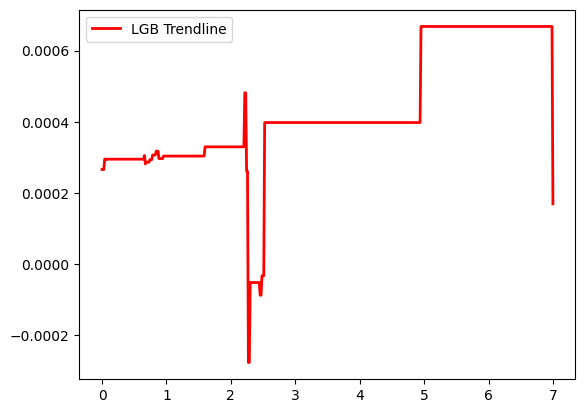

In [159]:
x_cur = rich_df["idiokurt"].to_numpy()
q5, q95 = np.percentile(x_cur, [5, 95])
print(q5, q95)
y_cur = rich_df["tgt_1"].to_numpy()


# Fit LightGBM trendline
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split

x_cur_2d = x_cur.reshape(-1, 1)
reg = lgb.LGBMRegressor(n_estimators=500, max_depth=3, learning_rate=0.001)
reg.fit(x_cur_2d, y_cur)

x_sorted = np.linspace(q5, q95, 500).reshape(-1, 1)
y_pred = reg.predict(x_sorted)

# plt.scatter(x_cur, y_cur, label="Data", alpha=0.1, s=1)
plt.plot(x_sorted, y_pred, color="red", label="LGB Trendline", linewidth=2)
plt.legend()
plt.show()


In [170]:
import statsmodels.api as sm
from sklearn.preprocessing import QuantileTransformer, StandardScaler

X = rich_df.select(
    ["wrv60", "xs_sigma", "idioskew", "idiokurt", "closing_range", "cema4", "cema20"]
).to_pandas()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

y = rich_df.select("tgt_2_4").to_series().to_numpy()
qt = QuantileTransformer(output_distribution="normal", random_state=0)
y = qt.fit_transform(y.reshape(-1, 1)).ravel()

model = sm.OLS(y, X_scaled)
results = model.fit()
pred = model.predict(results.params, X_scaled)

corr, pval = spearmanr(pred, y)
pcorr, _ = pearsonr(pred, y)
print(f"OLS\ts={100*corr:.2f}%, \tp={100*pcorr:.2f}%, \tp-value: {pval:.3f}")
print(results.summary())


OLS	s=4.98%, 	p=6.51%, 	p-value: 0.000
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):              0.004
Method:                 Least Squares   F-statistic:                              113.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                   1.54e-167
Time:                        19:12:26   Log-Likelihood:                     -2.6665e+05
No. Observations:              187704   AIC:                                  5.333e+05
Df Residuals:                  187697   BIC:                                  5.334e+05
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]